# Asian Options — Arithmetic Average Monte Carlo Pricing

## What is an Asian option?

An **Asian option** (also called an *average price option*) is a path-dependent derivative whose payoff depends on the **average** of the underlying price over the option's life, rather than its terminal value.

For an arithmetic average price call:

$$\text{Payoff} = \max\!\left(\bar{S} - K,\; 0\right), \quad \bar{S} = \frac{1}{n}\sum_{i=1}^{n} S_{t_i}$$

## Why averaging reduces volatility

The arithmetic mean of a path is less volatile than the terminal value of that path.  
Intuitively, extreme moves at individual time steps get smoothed away by the other observations.
Formally, if the underlying follows GBM with vol $\sigma$, the effective volatility of the average is approximately:

$$\sigma_{\text{avg}} \approx \frac{\sigma}{\sqrt{3}}$$

## Why Asian options are cheaper than Europeans

Because the payoff depends on a lower-volatility quantity ($\bar{S}$ instead of $S_T$), Asian options have **lower option value** than otherwise-identical European options.  
This makes them attractive for hedgers who are exposed to average prices over a period (e.g., commodity purchasers, FX treasury desks).

## Pricing approach

There is no closed-form solution for arithmetic Asian options.  
The `neon` library prices them via **Monte Carlo simulation**: simulate many GBM price paths, compute the arithmetic average along each path, evaluate the payoff, and discount the mean payoff back to present value.

In [1]:
%matplotlib inline
from neon.lib.instruments.options.option_inputs import OptionInputs
from neon.lib.instruments.options.option_type import OptionType
from neon.lib.instruments.options.asian import AsianOption
from neon.lib.instruments.options.european import EuropeanOption
from neon.lib.greeks.analytical_greeks import AnalyticalGreeks
import matplotlib.pyplot as plt
import numpy as np

# Shared market parameters
TICKER = "SPX"
SPOT = 100.0
STRIKE = 100.0
VOL = 0.20
RATE = 0.05
CURRENT_DATE = "20250101"
EXPIRY_DATE = "20260101"

## 1. ATM Asian vs European — Call and Put

Price an at-the-money Asian call and put, then compare to the Black-Scholes European price.
The Asian should be cheaper in both cases because averaging dampens the effective volatility.

In [2]:
call_inputs = OptionInputs(
    underlying_ticker=TICKER,
    underlying_price=SPOT,
    strike_price=STRIKE,
    volatility=VOL,
    risk_free_rate=RATE,
    current_date=CURRENT_DATE,
    expiry_date=EXPIRY_DATE,
    option_type=OptionType.Call,
)

put_inputs = OptionInputs(
    underlying_ticker=TICKER,
    underlying_price=SPOT,
    strike_price=STRIKE,
    volatility=VOL,
    risk_free_rate=RATE,
    current_date=CURRENT_DATE,
    expiry_date=EXPIRY_DATE,
    option_type=OptionType.Put,
)

# Asian options — Monte Carlo arithmetic average price
asian_call = AsianOption(call_inputs)
asian_put = AsianOption(put_inputs)

# European options — Black-Scholes analytical
euro_call = EuropeanOption(call_inputs, AnalyticalGreeks())
euro_put = EuropeanOption(put_inputs, AnalyticalGreeks())

asian_call_price = asian_call.price()
asian_put_price = asian_put.price()
euro_call_price = euro_call.price()
euro_put_price = euro_put.price()

print("ATM Prices (S=100, K=100, σ=20%, r=5%, T=1y)")
print(f"{'':20s}  {'Call':>10}  {'Put':>10}")
print("-" * 44)
print(f"{'Asian (MC)':20s}  {asian_call_price:>10.4f}  {asian_put_price:>10.4f}")
print(f"{'European (BS)':20s}  {euro_call_price:>10.4f}  {euro_put_price:>10.4f}")
print("-" * 44)
print(f"{'Averaging discount':20s}  {euro_call_price - asian_call_price:>10.4f}  {euro_put_price - asian_put_price:>10.4f}")

ATM Prices (S=100, K=100, σ=20%, r=5%, T=1y)
                            Call         Put
--------------------------------------------
Asian (MC)                5.8040      3.3657
European (BS)            10.4506      5.5735
--------------------------------------------
Averaging discount        4.6466      2.2078


## 2. Asian vs European Price Across Strikes

Sweep strikes from 85 to 115 (OTM through ITM) and compute Asian and European call prices.
The averaging discount is largest near the money and narrows for deep ITM/OTM options.

In [3]:
strikes = np.arange(85, 116, 5, dtype=float)

asian_call_prices = []
euro_call_prices = []
asian_put_prices = []
euro_put_prices = []

for k in strikes:
    c_inputs = OptionInputs(
        underlying_ticker=TICKER,
        underlying_price=SPOT,
        strike_price=float(k),
        volatility=VOL,
        risk_free_rate=RATE,
        current_date=CURRENT_DATE,
        expiry_date=EXPIRY_DATE,
        option_type=OptionType.Call,
    )
    p_inputs = OptionInputs(
        underlying_ticker=TICKER,
        underlying_price=SPOT,
        strike_price=float(k),
        volatility=VOL,
        risk_free_rate=RATE,
        current_date=CURRENT_DATE,
        expiry_date=EXPIRY_DATE,
        option_type=OptionType.Put,
    )
    asian_call_prices.append(AsianOption(c_inputs).price())
    euro_call_prices.append(EuropeanOption(c_inputs, AnalyticalGreeks()).price())
    asian_put_prices.append(AsianOption(p_inputs).price())
    euro_put_prices.append(EuropeanOption(p_inputs, AnalyticalGreeks()).price())

print(f"{'Strike':>8}  {'Asian Call':>12}  {'Euro Call':>12}  {'Discount':>10}  {'Asian Put':>11}  {'Euro Put':>10}")
print("-" * 72)
for k, ac, ec, ap, ep in zip(strikes, asian_call_prices, euro_call_prices, asian_put_prices, euro_put_prices):
    disc = ec - ac
    print(f"{k:>8.0f}  {ac:>12.4f}  {ec:>12.4f}  {disc:>10.4f}  {ap:>11.4f}  {ep:>10.4f}")

  Strike    Asian Call     Euro Call    Discount    Asian Put    Euro Put
------------------------------------------------------------------------
      85       16.9133       20.4693      3.5560       0.2095      1.3238
      90       12.5528       16.6994      4.1467       0.6730      2.3101
      95        8.8524       13.3465      4.4941       1.6725      3.7133
     100        5.7463       10.4506      4.7043       3.3513      5.5735
     105        3.5057        8.0214      4.5156       5.8408      7.9004
     110        2.0204        6.0401      4.0197       9.0588     10.6753
     115        1.0711        4.4666      3.3954      12.9347     13.8580


## 3. Plot — Asian Call vs European Call by Strike

The shaded region between the two curves is the **averaging discount** — the value given up by replacing the terminal payoff with an average payoff.  
It peaks near the money where optionality is most sensitive to realized volatility.

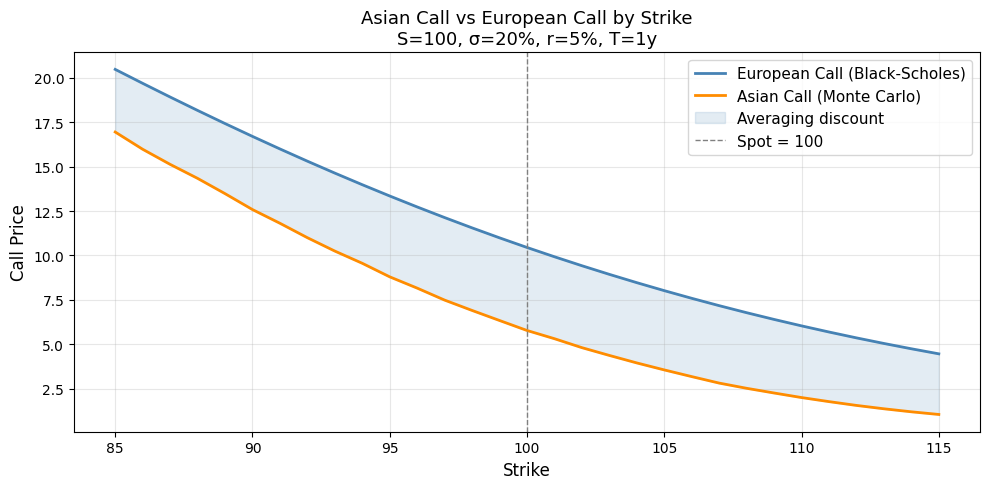

In [4]:
# Use a finer strike grid for a smooth curve
strikes_fine = np.arange(85, 116, dtype=float)

asian_fine = []
euro_fine = []

for k in strikes_fine:
    c_inputs = OptionInputs(
        underlying_ticker=TICKER,
        underlying_price=SPOT,
        strike_price=float(k),
        volatility=VOL,
        risk_free_rate=RATE,
        current_date=CURRENT_DATE,
        expiry_date=EXPIRY_DATE,
        option_type=OptionType.Call,
    )
    asian_fine.append(AsianOption(c_inputs).price())
    euro_fine.append(EuropeanOption(c_inputs, AnalyticalGreeks()).price())

asian_fine = np.array(asian_fine)
euro_fine = np.array(euro_fine)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(strikes_fine, euro_fine, color="steelblue", linewidth=2, label="European Call (Black-Scholes)")
ax.plot(strikes_fine, asian_fine, color="darkorange", linewidth=2, label="Asian Call (Monte Carlo)")
ax.fill_between(strikes_fine, asian_fine, euro_fine, alpha=0.15, color="steelblue", label="Averaging discount")

ax.axvline(SPOT, color="gray", linestyle="--", linewidth=1, label=f"Spot = {SPOT:.0f}")

ax.set_xlabel("Strike", fontsize=12)
ax.set_ylabel("Call Price", fontsize=12)
ax.set_title("Asian Call vs European Call by Strike\nS=100, σ=20%, r=5%, T=1y", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()